## Pennsylvania - 2 pfts 

#### Libraries

In [1]:
import numpy as np
import xarray as xr
import csv
import pandas as pd
import os
import netCDF4 as nc4
import sys

import functions_py.fates_xarray_functions as fa

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from matplotlib import cm
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm
from mpl_toolkits.mplot3d import Axes3D

from shapely.geometry import Polygon

/global/homes/j/jneedham/.conda/envs/myenv/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
dark = cm.get_cmap('Paired', 12)
colormap = dark(range(12))

#### Load the FATES runs  
- note we did this in four cases each with 250 members

In [3]:
fates1='/pscratch/sd/j/jneedham/fates-mrv-runs/runs/PA_ensemble_1_v2.Eddc844b10d-Fd554ed4a.2025-03-14/run/PA_ensemble_1_v2.Eddc844b10d-Fd554ed4a.2025-03-14.h0.ensemble.sofar.nc'
fates1 = xr.open_dataset(fates1,  decode_times=False)

fates2='/pscratch/sd/j/jneedham/fates-mrv-runs/runs/PA_ensemble_2_v2.Eddc844b10d-Fd554ed4a.2025-03-14/run/PA_ensemble_2_v2.Eddc844b10d-Fd554ed4a.2025-03-14.h0.ensemble.sofar.nc'
fates2 = xr.open_dataset(fates2,  decode_times=False)

#fates = xr.concat([fates1, fates2], dim='record')

In [4]:
nyears = int(len(fates1.variables['time']))
print(nyears)

nyears = int(len(fates2.variables['time']))
print(nyears)

4200
3600


Get rid of the last 50 years of ensemble  1 so they are all the same length 

In [5]:
fates1 = fates1.isel(time=slice(0,3600))

nyears = int(len(fates1.variables['time']))
print(nyears)

3600


In [6]:
fates = xr.concat([fates1, fates2], dim='record')

In [7]:
nyears = int(len(fates.variables['time'])/12)
print(nyears)
time = fates.variables['time'] / 365.

tave_start = (nyears*12-20*12)
tave_stop = nyears*12

print(tave_start)
print(tave_stop)

cohort_size_bins = fates.variables['fates_levscls'][:]
nsizebins = len(cohort_size_bins)
patch_age_bins = fates.variables['fates_levage'][:]

n_lon = len(fates.variables['lon'])
ninst = n_lon
print(ninst)

300
3360
3600
500


### Veg C through time 

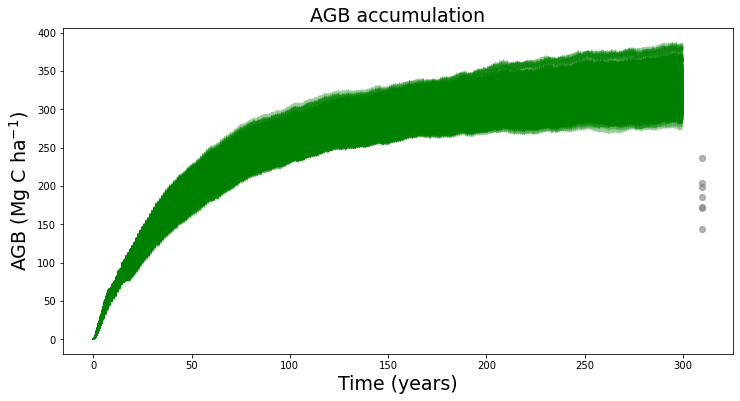

In [8]:
AGB = fates.FATES_VEGC_ABOVEGROUND_SZPF  * 10000 * 0.001 * 2
AGB = AGB.sum(dim='fates_levscpf')

fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

for  i in range(0,ninst):
    if i == 0: 
        f1ax0.plot(time, AGB[i], color='green', label = 'FATES', alpha = 0.4)    
    else: 
        f1ax0.plot(time, AGB[i,:], color='green', alpha = 0.4)

f1ax0.set_title(r'AGB accumulation', fontsize = 19)
f1ax0.set_ylabel(r'AGB (Mg C ha$^{-1}$)', fontsize = 19)
f1ax0.set_xlabel(r'Time (years)', fontsize = 19)    
;

gedi_x = [310,310,310,310,310,310,310]
gedi_y = [171.59, 172.45, 185.59, 143.95, 203.19, 198.31, 236.16] # Mg ha-1 - aboveground biomass density 

f1ax0.scatter(gedi_x, gedi_y, alpha=0.6, color='grey')

In [9]:
print(np.mean(gedi_y))

187.32


### How many ensemble members have coexistence 

In [10]:
vegc = fates.FATES_VEGC_PF

coex = []
vegc1_frac = []
vegc2_frac = []


vegc1 = []
vegc2 = []
vegctotal = []

for i in range(0,ninst):
    veg =  vegc.isel(record=i)
    # percent total  biomass of each tree PFT
    vegcfinal = veg.isel(time=3599)
    total = vegcfinal.sum(dim=('fates_levpft'))
    pft1 = (vegcfinal.isel(fates_levpft=0)  / total ).values
    pft2 = (vegcfinal.isel(fates_levpft=1)  / total ).values
    
    vegc1_frac.append(pft1)
    vegc2_frac.append(pft2)
    
    vegc1.append(vegcfinal.isel(fates_levpft=0).values)
    vegc2.append(vegcfinal.isel(fates_levpft=1).values)
    
    vegctotal.append(total)
                 
     # make sure no PFT has more than 80% of biomass 
    if (pft1 < 0.8 and pft2 < 0.8 ) :
        coex.append(i)
    
        
print(len(coex))   

225


### Which ensemble members have high coexistence PFT 1 and PFT 2
No pft  with more than 80% of  biomass

In [11]:
vegc2_prop = np.concatenate(vegc2_frac).tolist()
vegc1_prop = np.concatenate(vegc1_frac).tolist()

In [19]:
indices = [index for index,value in enumerate(vegc1_prop) if 0.2 < value < 0.8]
print(len(indices))

225


(500, 3600, 2, 1)


IndexError: index 100 is out of bounds for axis 0 with size 100

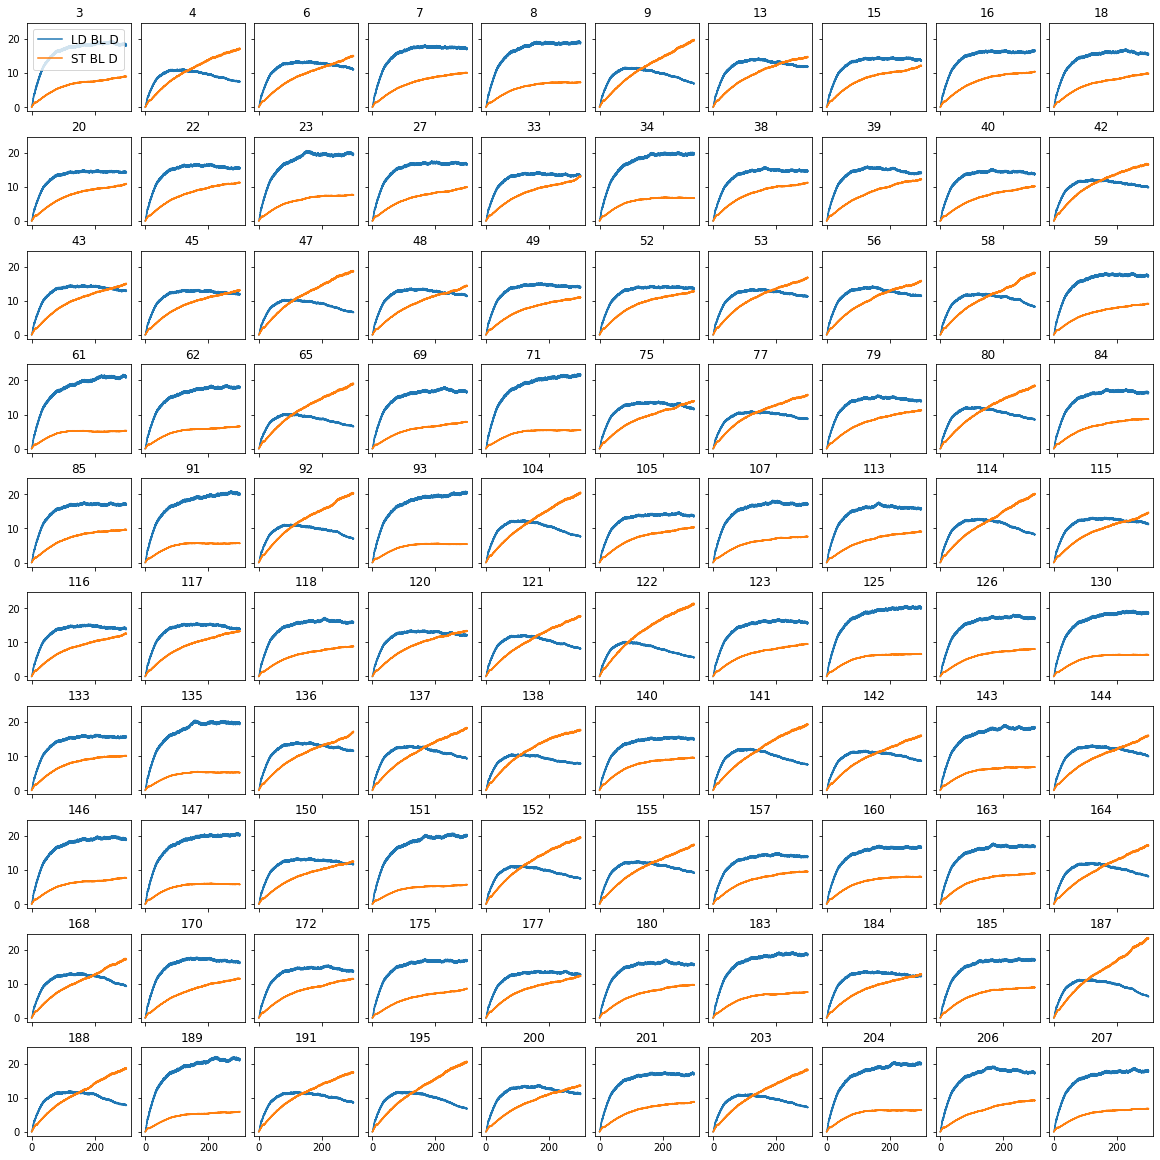

In [21]:
AGB = fates.FATES_VEGC_PF

print(AGB.shape)

fig1, axs = plt.subplots(nrows=10,ncols=10, figsize=(16,16), constrained_layout=True, sharex=True, sharey=True)
axs=axs.flatten()

for  i in range(0,99):
    axs[i].plot(time, AGB[indices[i],:,0],label = 'LD BL D')  
    axs[i].plot(time, AGB[indices[i],:,1], label = 'ST BL D')      
    axs[i].set_title(indices[i])
    if i == 0:
        axs[i].legend(prop={'size':12})

fig1.supxlabel(r'Time (Years)', fontsize=16)
fig1.supylabel(r'Vegc (kg C m-2)', fontsize=16)

        

### Ensemble members within 10% of GEDI  mean

In [22]:
gedi_mean = np.mean(gedi_y)
print(gedi_mean)

187.32


In [23]:
AGB = fates.FATES_VEGC_ABOVEGROUND_SZPF  * 10000 * 0.001 * 2
AGB = AGB.sum(dim='fates_levscpf')
print(AGB.shape)
AGB_tend = np.squeeze(AGB.isel(time=slice(tave_start,tave_stop)).mean(dim='time'))
print(AGB_tend.shape)

(500, 3600, 1)
(500,)


In [37]:
indices_gedi = [i for i, value in enumerate(AGB_tend) if value > gedi_mean * 0.46 and value < gedi_mean*1.54]

print(len(indices_gedi))

14


(500, 3600, 2, 1)


Text(0.02, 0.5, 'Vegc (kg C m-2)')

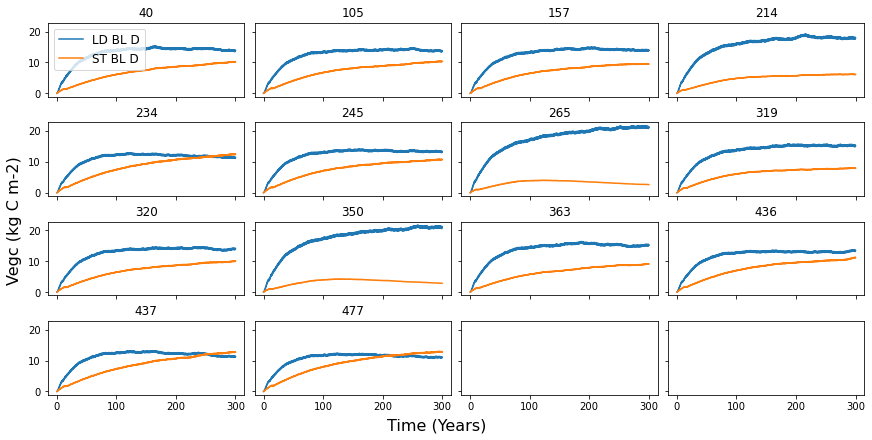

In [38]:
AGB = fates.FATES_VEGC_PF

print(AGB.shape)

fig1, axs = plt.subplots(nrows=4,ncols=4, figsize=(12,6), constrained_layout=True, sharex=True, sharey=True)
axs=axs.flatten()

for  i in range(0,len(indices_gedi)):
    axs[i].plot(time, AGB[indices_gedi[i],:,0],label = 'LD BL D')  
    axs[i].plot(time, AGB[indices_gedi[i],:,1], label = 'ST BL D')      
    axs[i].set_title(indices_gedi[i])
    if i == 0:
        axs[i].legend(prop={'size':12})

fig1.supxlabel(r'Time (Years)', fontsize=16)
fig1.supylabel(r'Vegc (kg C m-2)', fontsize=16)

        

###  Ensemble members with coexistence, early cross over point and lowest biomass

In [ ]:
#print(indices)
#print(indices_gedi)
#overlap = list(set(indices) & set(indices_gedi))
#print(overlap)

In [ ]:
# find ensemble where ST > LD in year 100 

In [47]:
vegc = fates.FATES_VEGC_PF

coex = []
total300 = []

for i in range(0,ninst):
    veg =  vegc.isel(record=i)
    # percent total  biomass of each tree PFT
    vegc100 = veg.isel(time=1200)
    vegc50 = veg.isel(time=600)
    
    
    total100 = vegc100.sum(dim=('fates_levpft'))
    pft1_100 = (vegc100.isel(fates_levpft=0)  / total100 ).values
    total50 = vegc50.sum(dim=('fates_levpft'))
    pft1_50 = (vegc50.isel(fates_levpft=0)  / total50 ).values

    if (pft1_50 > 0.5 and pft1_100 < 0.5 ) :
        coex.append(i)
        total300.append(veg.isel(time=3599).sum(dim='fates_levpft'))
    
        
print(len(coex)) 
print(len(total300))

61
61


(500, 3600, 2, 1)


Text(0.02, 0.5, 'Vegc (kg C m-2)')

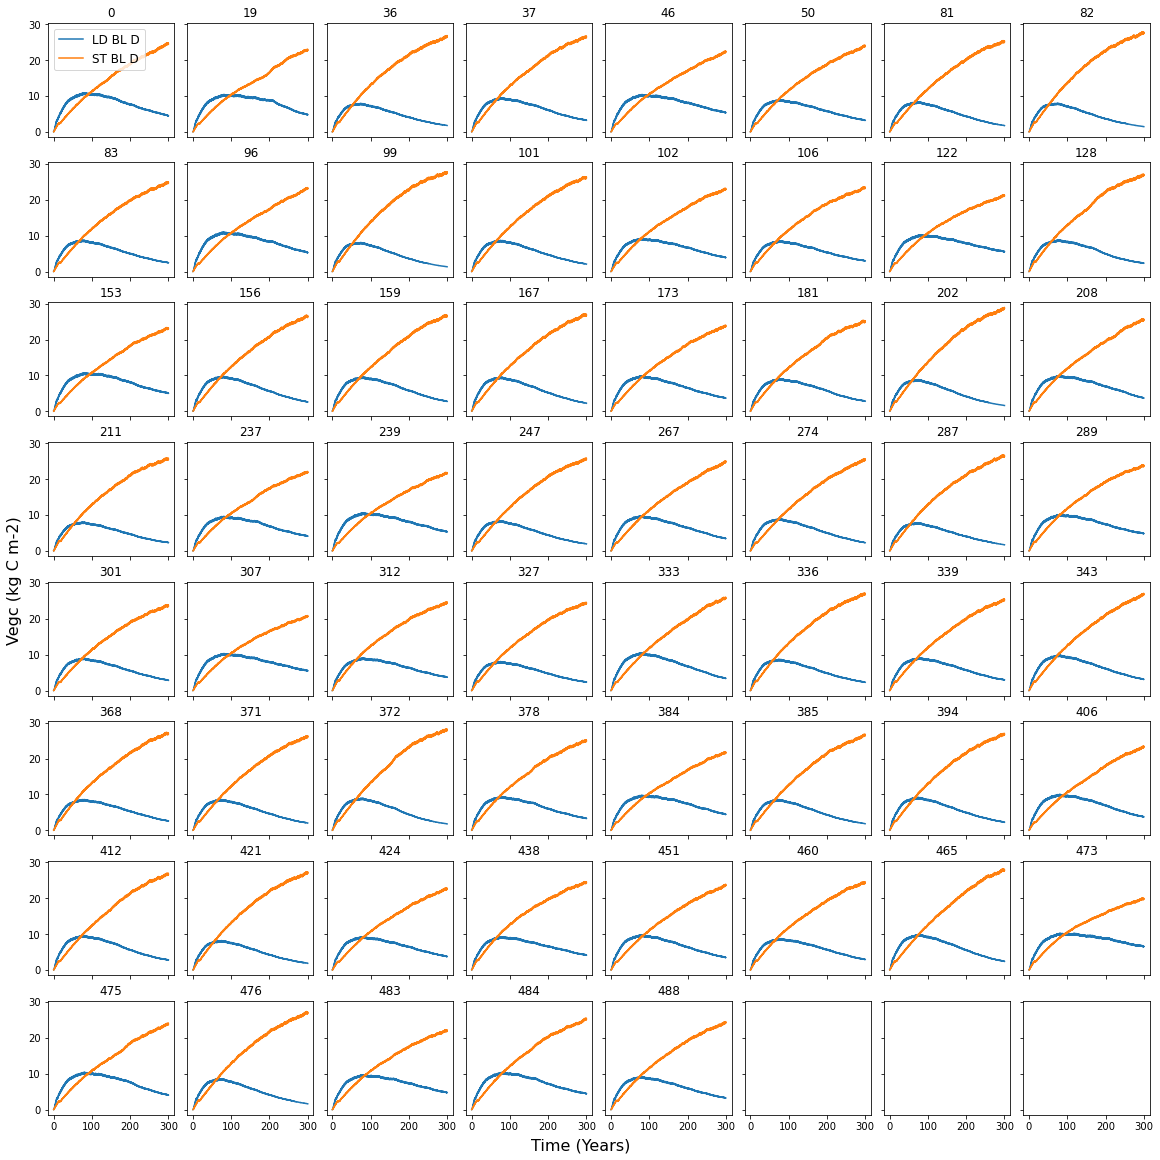

In [46]:
AGB = fates.FATES_VEGC_PF

print(AGB.shape)

fig1, axs = plt.subplots(nrows=8,ncols=8, figsize=(16,16), constrained_layout=True, sharex=True, sharey=True)
axs=axs.flatten()

for  i in range(0,len(coex)):
    axs[i].plot(time, AGB[coex[i],:,0],label = 'LD BL D')  
    axs[i].plot(time, AGB[coex[i],:,1], label = 'ST BL D')      
    axs[i].set_title(coex[i])
    if i == 0:
        axs[i].legend(prop={'size':12})

fig1.supxlabel(r'Time (Years)', fontsize=16)
fig1.supylabel(r'Vegc (kg C m-2)', fontsize=16)

### Which of these has the lowest biomass? 

In [58]:
AGB = fates.FATES_VEGC_ABOVEGROUND_SZPF  * 10000 * 0.001 * 2
AGB = AGB.sum(dim='fates_levscpf')
AGB = AGB.sel(record = coex)
AGB = np.squeeze(AGB.isel(time=slice(3480,3599)).mean(dim='time'))

In [59]:
print(AGB)

<xarray.DataArray 'FATES_VEGC_ABOVEGROUND_SZPF' (record: 61)>
array([349.24005, 331.67352, 339.12103, 356.1127 , 331.57706, 325.2261 ,
       323.0479 , 348.1219 , 326.97006, 341.82147, 346.4395 , 340.0472 ,
       322.45554, 316.2183 , 320.9816 , 349.77084, 338.12668, 348.66968,
       352.75052, 349.82455, 328.40305, 334.94485, 361.9444 , 350.62762,
       336.0414 , 313.01697, 324.53162, 330.04007, 338.40738, 332.12927,
       338.39142, 343.51654, 319.30975, 314.96808, 338.31253, 320.75027,
       350.61563, 350.8037 , 338.5222 , 358.6387 , 355.80118, 336.85583,
       356.621  , 339.4804 , 313.38947, 339.35242, 347.98767, 323.18024,
       353.79028, 346.82715, 316.82083, 342.8056 , 324.35553, 327.55618,
       363.61972, 317.40958, 335.13568, 343.76538, 322.08017, 356.22778,
       329.73254], dtype=float32)
Dimensions without coordinates: record


In [61]:
np.where(AGB == np.min(AGB))

(array([25]),)

In [64]:
coex[25]

237

In [65]:
fates_best = fates.isel(record=237)

### Size distribution

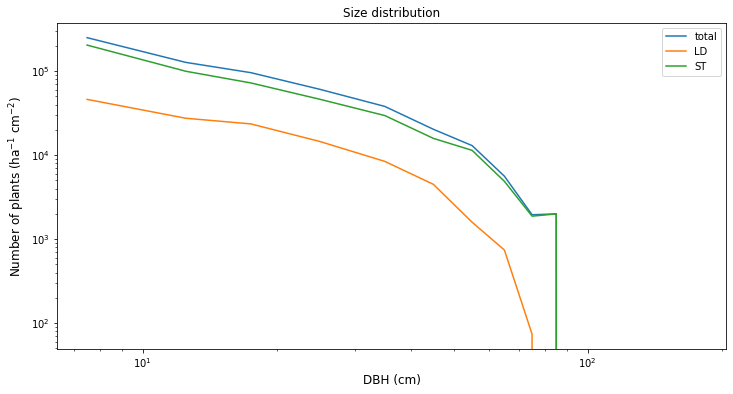

In [66]:
# size bins are LOWER bounds. Remove the fist bin - but add an extra bin to catch trees over last bin edge
cohort_size_bins_ex = np.append(cohort_size_bins[1:], 250)
fates_sizebin_mids = (cohort_size_bins_ex[0:-1] + cohort_size_bins_ex[1:])/2
fates_sizebin_widths = cohort_size_bins_ex[1:] - cohort_size_bins_ex[:-1]

NPLANT_SZPF = fa.scpf_to_scls_by_pft(fates_best.FATES_NPLANT_SZPF, fates_best) * 10000
NPLANT_SZ =  NPLANT_SZPF.sum(dim='fates_levpft')

nplant = NPLANT_SZ.isel(time=slice(tave_start,tave_stop)).mean(dim='time') * 10000 # convert to plants per ha (from m-2)
nplant = np.squeeze(nplant)
fates_sd = np.squeeze(nplant[1:,])/fates_sizebin_widths

nplant1 = NPLANT_SZPF.isel(fates_levpft=0)
nplant2 = NPLANT_SZPF.isel(fates_levpft=1)

nplant1 = nplant1.isel(time=slice(tave_start,tave_stop)).mean(dim='time') * 10000
nplant2 = nplant2.isel(time=slice(tave_start,tave_stop)).mean(dim='time') * 10000
nplant1 = np.squeeze(nplant1)
nplant2 = np.squeeze(nplant2)

fates_sd1 = np.squeeze(nplant1[1:,])/fates_sizebin_widths
fates_sd2 = np.squeeze(nplant2[1:,])/fates_sizebin_widths

fig2, ((f2ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f2ax0.plot(fates_sizebin_mids, fates_sd,  label = 'total')
f2ax0.plot(fates_sizebin_mids, fates_sd1,  label = 'LD')
f2ax0.plot(fates_sizebin_mids, fates_sd2,  label = 'ST')
    
f2ax0.set_title(r'Size distribution', fontsize = 12)
f2ax0.set_ylabel(r'Number of plants (ha$^{-1}$ cm$^{-2}$)', fontsize = 12)
f2ax0.set_xlabel(r'DBH (cm)', fontsize = 12)    

f2ax0.legend()
f2ax0.set_yscale('log')
f2ax0.set_xscale('log')

### Population size and AGB through time by size

(3600, 1, 13)


Text(0, 0.5, 'Cohort Size (cm)')

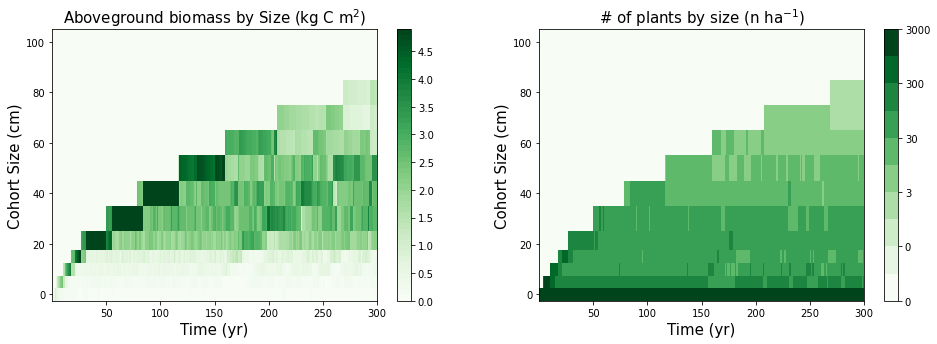

In [67]:
# population numbers as a function of cohort size
NPLANT_SZPF = fa.scpf_to_scls_by_pft(fates_best.FATES_NPLANT_SZPF, fates_best) * 10000
NPLANT_SZ =  NPLANT_SZPF.sum(dim='fates_levpft')

VEGC_ABOVEGROUND_SZPF = fa.scpf_to_scls_by_pft(fates_best.FATES_VEGC_ABOVEGROUND_SZPF, fates_best)
VEGC_ABOVEGROUND_SZ  = VEGC_ABOVEGROUND_SZPF.sum(dim='fates_levpft')
print(VEGC_ABOVEGROUND_SZ.shape)

fig2, ((f2ax0, f2ax1)) = plt.subplots(nrows=1,ncols=2, figsize=(16,5))

## set up the first plot: evolution of AGB of plants of a given size
levels = np.arange(0.,5, 0.1)
cmap = plt.get_cmap('Greens')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f2ax0.pcolormesh(time, cohort_size_bins, VEGC_ABOVEGROUND_SZ[:,0,:].transpose(), cmap=cmap, norm=norm)
fig2.colorbar(im, ax=f2ax0)
f2ax0.set_title(r'Aboveground biomass by Size (kg C m$^2$)', fontsize=15)
f2ax0.set_xlabel('Time (yr)', fontsize=15)
f2ax0.set_ylabel('Cohort Size (cm)', fontsize=15)

levels = np.array([0, 0.1,0.3,1.,3.,10.,30., 100., 300., 1000., 3000]) # do a pseudo-log scale here
cmap = plt.get_cmap('Greens')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f2ax1.pcolormesh(time, cohort_size_bins, (NPLANT_SZ)[:,0,:].transpose(),
                      cmap=cmap, norm=norm)
fig2.colorbar(im, ax=f2ax1)
f2ax1.set_title(r'# of plants by size (n ha$^{-1}$)', fontsize=15)
f2ax1.set_xlabel('Time (yr)', fontsize=15)
f2ax1.set_ylabel('Cohort Size (cm)', fontsize=15)